In [1]:
import os, glob
import numpy as np
import torch
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, confusion_matrix
import matplotlib.pyplot as plt
import umap
from transformers import AutoImageProcessor, AutoModel


In [2]:
from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/content/pureforest"
SPECIES = ["Fagus_sylvatica", "Larix_decidua", "Pinus_halepensis"]
MAX_PER_SPECIES = 100

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
paths, labels = [], []
for label_id, species in enumerate(SPECIES):
    folder = os.path.join(ROOT, species)
    files = sorted(glob.glob(os.path.join(folder, "*.tiff")) +
                   glob.glob(os.path.join(folder, "*.tif")))[:MAX_PER_SPECIES]
    paths  += files
    labels += [label_id] * len(files)
    print(f"{species}: {len(files)} images")

labels = np.array(labels)
print(f"\nTotal: {len(paths)} images")

Fagus_sylvatica: 100 images
Larix_decidua: 100 images
Pinus_halepensis: 100 images

Total: 300 images


In [4]:
!pip install -q transformers

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")

def tiff_to_pil(path):
    """Load uint16 4-channel TIFF, extract R/G/B, percentile-clip to uint8 PIL Image."""
    arr = np.array(Image.open(path))           # (H, W, 4) uint16 — NIR=0,R=1,G=2,B=3
    rgb = arr[:, :, 1:4]                       # R=1, G=2, B=3 only (DINOv2 = 3-ch)
    out = np.zeros_like(rgb, dtype=np.uint8)
    for i in range(3):
        ch = rgb[:, :, i].astype(np.float32)
        lo, hi = np.percentile(ch, 2), np.percentile(ch, 98)
        out[:, :, i] = np.clip((ch - lo) / (hi - lo + 1e-6) * 255, 0, 255).astype(np.uint8)
    return Image.fromarray(out, mode="RGB")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"


dino = AutoModel.from_pretrained("facebook/dinov2-base").to(device).eval()

BATCH = 16   
features = []
for i in range(0, len(paths), BATCH):
    imgs = [tiff_to_pil(p) for p in paths[i:i+BATCH]]
    inputs = processor(images=imgs, return_tensors="pt").to(device)
    with torch.no_grad():
        out = dino(**inputs)
    features.append(out.last_hidden_state[:, 0, :].cpu().numpy())  # CLS token
    print(f"  {i+len(imgs)}/{len(paths)}", end="\r")

X = np.vstack(features)
print(f"\nFeature matrix: {X.shape}")   # (N, 768)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

/tmp/ipykernel_10883/1684791721.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="RGB")


  300/300
Feature matrix: (300, 768)


In [6]:
X_pca = PCA(n_components=50, random_state=42).fit_transform(X)

# K-Means
y_kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_pca)

# GMM
gmm = GaussianMixture(n_components=3, covariance_type="full", n_init=5, random_state=42).fit(X_pca)
y_gmm = gmm.predict(X_pca)

y_pred = y_kmeans  # keep y_pred for backward compatibility


KMeans    NMI: 0.258   ARI: 0.255
GMM       NMI: 0.271   ARI: 0.266


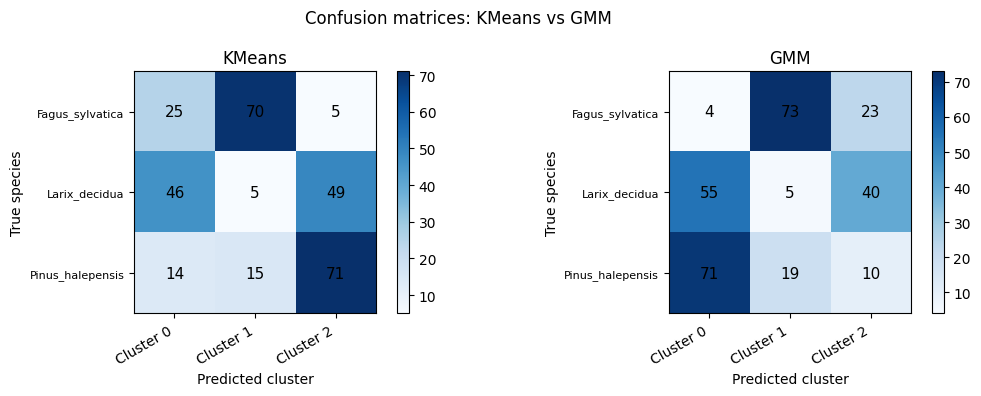

In [7]:
for method, y_pred_m in [("KMeans", y_kmeans), ("GMM", y_gmm)]:
    nmi = normalized_mutual_info_score(labels, y_pred_m)
    ari = adjusted_rand_score(labels, y_pred_m)
    print(f"{method:8s}  NMI: {nmi:.3f}   ARI: {ari:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (method, y_pred_m) in zip(axes, [("KMeans", y_kmeans), ("GMM", y_gmm)]):
    cm = confusion_matrix(labels, y_pred_m)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels([f"Cluster {i}" for i in range(3)], rotation=30, ha="right")
    ax.set_yticklabels(SPECIES, fontsize=8)
    ax.set_xlabel("Predicted cluster"); ax.set_ylabel("True species")
    ax.set_title(method)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11)
    plt.colorbar(im, ax=ax)

plt.suptitle("Confusion matrices: KMeans vs GMM")
plt.tight_layout(); plt.show()


k=2  KM inertia=185195  KM sil=0.154 | GMM BIC=82778  GMM AIC=72960  GMM sil=0.155
k=3  KM inertia=165898  KM sil=0.118 | GMM BIC=85516  GMM AIC=70786  GMM sil=0.120
k=4  KM inertia=154309  KM sil=0.122 | GMM BIC=88118  GMM AIC=68477  GMM sil=0.079
k=5  KM inertia=147727  KM sil=0.115 | GMM BIC=81066  GMM AIC=56514  GMM sil=0.119
k=6  KM inertia=143166  KM sil=0.095 | GMM BIC=69259  GMM AIC=39795  GMM sil=0.108


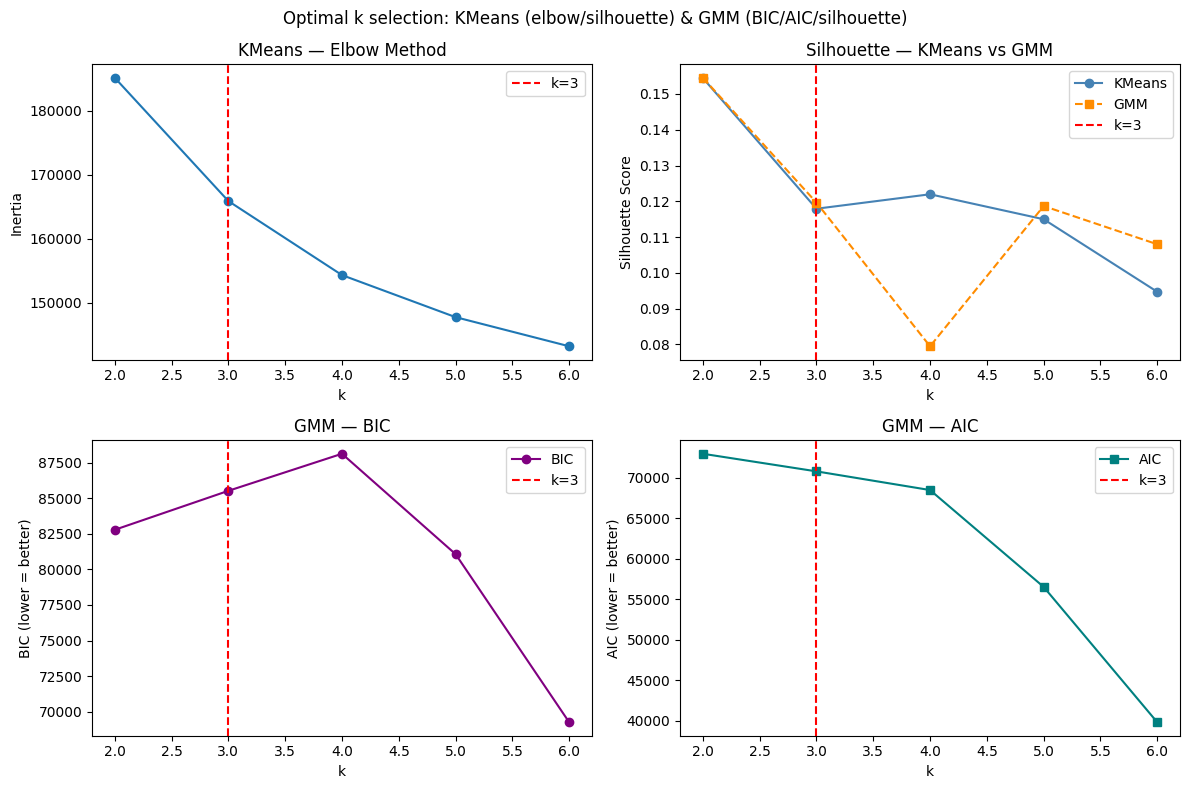

In [8]:
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 7)
inertias, silhouettes_km = [], []
bic_scores, aic_scores, silhouettes_gmm = [], [], []

for k in K_RANGE:
    # K-Means
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X_pca, km.labels_, sample_size=500))

    # GMM
    gm = GaussianMixture(n_components=k, covariance_type="full", n_init=5, random_state=42).fit(X_pca)
    bic_scores.append(gm.bic(X_pca))
    aic_scores.append(gm.aic(X_pca))
    silhouettes_gmm.append(silhouette_score(X_pca, gm.predict(X_pca), sample_size=500))

    print(f"k={k}  KM inertia={inertias[-1]:.0f}  KM sil={silhouettes_km[-1]:.3f} | "
          f"GMM BIC={bic_scores[-1]:.0f}  GMM AIC={aic_scores[-1]:.0f}  GMM sil={silhouettes_gmm[-1]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(K_RANGE, inertias, "o-")
axes[0, 0].axvline(3, color="red", linestyle="--", label="k=3")
axes[0, 0].set_xlabel("k"); axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_title("KMeans — Elbow Method"); axes[0, 0].legend()

axes[0, 1].plot(K_RANGE, silhouettes_km, "o-", color="steelblue", label="KMeans")
axes[0, 1].plot(K_RANGE, silhouettes_gmm, "s--", color="darkorange", label="GMM")
axes[0, 1].axvline(3, color="red", linestyle="--", label="k=3")
axes[0, 1].set_xlabel("k"); axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_title("Silhouette — KMeans vs GMM"); axes[0, 1].legend()

axes[1, 0].plot(K_RANGE, bic_scores, "o-", color="purple", label="BIC")
axes[1, 0].axvline(3, color="red", linestyle="--", label="k=3")
axes[1, 0].set_xlabel("k"); axes[1, 0].set_ylabel("BIC (lower = better)")
axes[1, 0].set_title("GMM — BIC"); axes[1, 0].legend()

axes[1, 1].plot(K_RANGE, aic_scores, "s-", color="teal", label="AIC")
axes[1, 1].axvline(3, color="red", linestyle="--", label="k=3")
axes[1, 1].set_xlabel("k"); axes[1, 1].set_ylabel("AIC (lower = better)")
axes[1, 1].set_title("GMM — AIC"); axes[1, 1].legend()

plt.suptitle("Optimal k selection: KMeans (elbow/silhouette) & GMM (BIC/AIC/silhouette)")
plt.tight_layout(); plt.show()
